Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
(1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), 

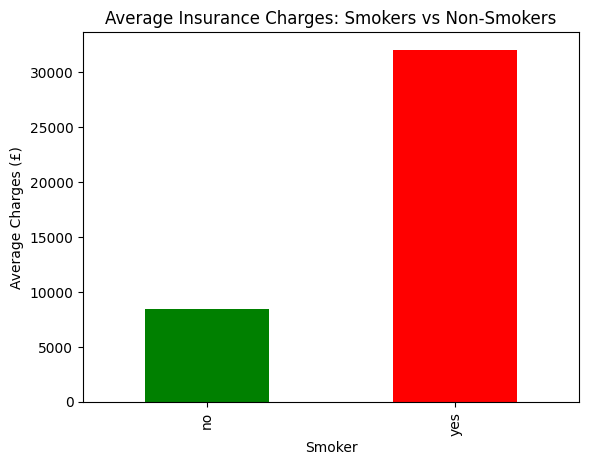

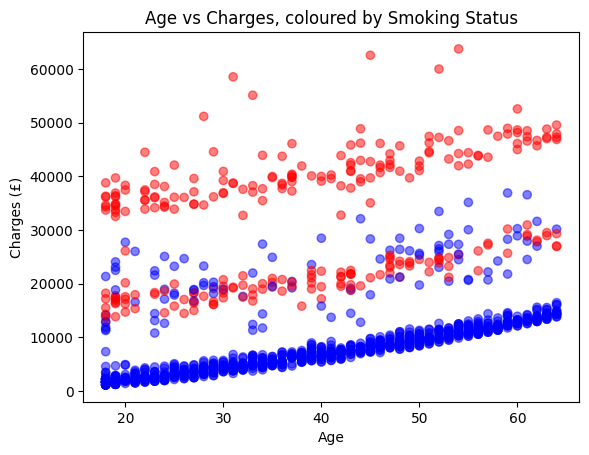

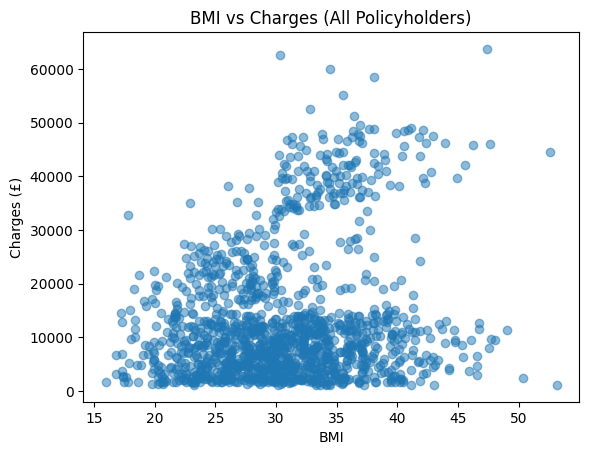

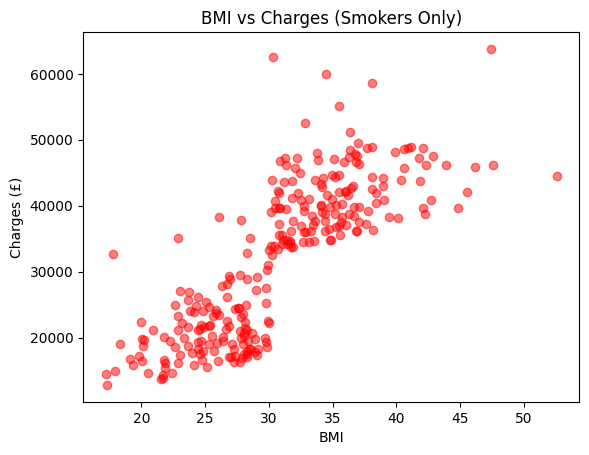

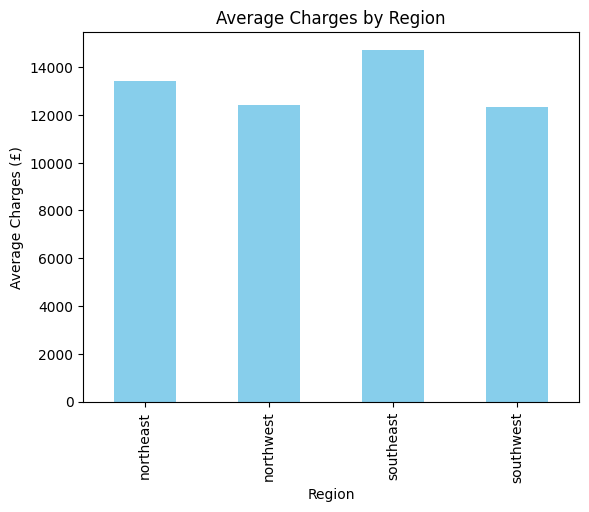

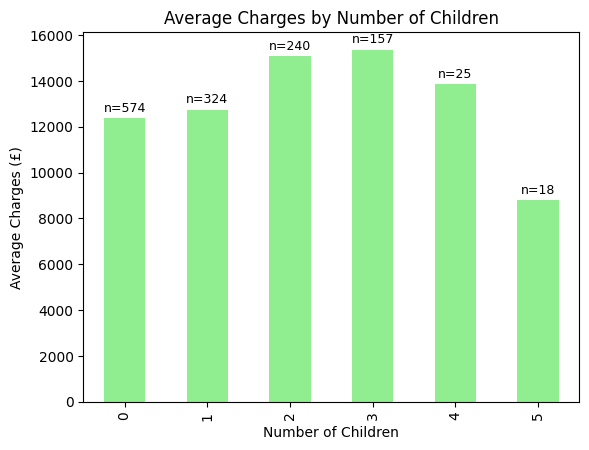

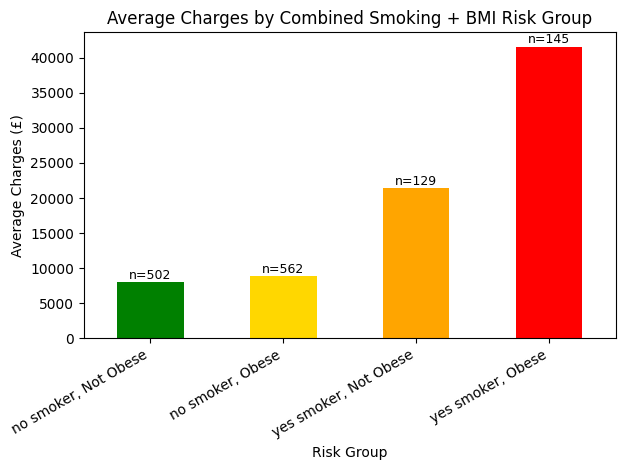

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/project 1/insurance.csv')
print(df.head())
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())


 # Q1 - Does smoking status effect charges if so, by how much?

print(df.groupby('smoker')['charges'].mean())  # This calculates average charges grouped by smoking status
print(df.groupby('smoker')['charges'].describe())


# Bar chart comparing average charges by smoking status
df.groupby('smoker')['charges'].mean().plot(kind='bar', color=['green', 'red'])
plt.title('Average Insurance Charges: Smokers vs Non-Smokers')
plt.ylabel('Average Charges (£)')
plt.xlabel('Smoker')
plt.show()

# Q2 - Does age correlate with charges?

colors = df['smoker'].map({'yes': 'red', 'no': 'blue'})
plt.scatter(df['age'], df['charges'], c=colors, alpha=0.5)
plt.title('Age vs Charges, coloured by Smoking Status')
plt.xlabel('Age')
plt.ylabel('Charges (£)')
plt.show()

# Q3 - Does BMI correlate with charges?

# First check BMI vs charges for everyone
plt.scatter(df['bmi'], df['charges'], alpha=0.5)
plt.title('BMI vs Charges (All Policyholders)')
plt.xlabel('BMI')
plt.ylabel('Charges (£)')
plt.show()

# check BMI vs charges for smokers only, since the age chart
# suggested smoking and BMI might interact
smokers = df[df['smoker'] == 'yes'].copy()
plt.scatter(smokers['bmi'], smokers['charges'], alpha=0.5, color='red')
plt.title('BMI vs Charges (Smokers Only)')
plt.xlabel('BMI')
plt.ylabel('Charges (£)')
plt.show()

# Quantify the split: smokers above vs below BMI 30 (obesity threshold)
smokers['bmi_category'] = smokers['bmi'].apply(lambda x: 'Obese (BMI 30+)' if x >= 30 else 'Not Obese (BMI <30)')
smokers.groupby('bmi_category')['charges'].mean()

# Q4 - Do charges differ by region?

df.groupby('region')['charges'].mean()
df.groupby('region')['charges'].mean().plot(kind='bar', color='skyblue')
plt.title('Average Charges by Region')
plt.ylabel('Average Charges (£)')
plt.xlabel('Region')
plt.show()

# Q5 - Does number of children affect charges?

means = df.groupby('children')['charges'].mean()
counts = df.groupby('children')['charges'].count()

ax = means.plot(kind='bar', color='lightgreen')
plt.title('Average Charges by Number of Children')
plt.ylabel('Average Charges (£)')
plt.xlabel('Number of Children')

# count labels for each bar
for i, (mean_val, count_val) in enumerate(zip(means, counts)):
    plt.text(i, mean_val + 300, f'n={count_val}', ha='center', fontsize=9)

plt.show()

# Q6 - FINAL QUESTION - How does the combination of smoking and BMI effect charges?
df_copy = df.copy()
df_copy['bmi_category'] = df_copy['bmi'].apply(lambda x: 'Obese' if x >= 30 else 'Not Obese')
df_copy['risk_group'] = df_copy['smoker'] + ' smoker, ' + df_copy['bmi_category']

combined = df_copy.groupby('risk_group')['charges'].mean().sort_values()
counts = df_copy.groupby('risk_group')['charges'].count()

ax = combined.plot(kind='bar', color=['green', 'gold', 'orange', 'red'])
plt.title('Average Charges by Combined Smoking + BMI Risk Group')
plt.ylabel('Average Charges (£)')
plt.xlabel('Risk Group')
plt.xticks(rotation=30, ha='right')

for i, (mean_val, count_val) in enumerate(zip(combined, counts.reindex(combined.index))):
    plt.text(i, mean_val + 500, f'n={count_val}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()